# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [14]:
#code here
class NANDperceptron:
  def __init__(self):
    self.weights=np.array([-2.0,-2.0])
    self.bias=3.0
  def activate(self,X):
    z = X @ self.weights + self.bias
    return (z>=0).astype(int)
nand = NANDperceptron()

inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

outputs = nand.activate(inputs)

print("Inputs (N, 2):\n", inputs)
print("\nNAND Outputs:\n", outputs)

Inputs (N, 2):
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]

NAND Outputs:
 [1 1 1 0]


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:** activation function inperceptron is a step function (Heaviside step function). this is a discontinuous/discrete function.
it is a system of switch on/off system. Even a tiny change in a single weight can cause the weighted input sum ($w \cdot x + b$) to flip from slightly negative to slightly positive. This flips the neuron's output completely from 0 to 1, causing a massive ripple effect (chaos) across subsequent layers in the network, making smooth learning impossible.

### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **Your answer:**

sigma= 1/(1+e^-z)


As $c \to \infty$ (approaches infinity), the sigmoid neuron behaves exactly like a classic perceptron. Mathematically, the modified sigmoid is $\sigma(cz) = \frac{1}{1 + e^{-cz}}$. As $c$ becomes extremely large:If $z > 0$, $e^{-cz} \to 0$, so $\sigma(cz) \to 1$.If $z < 0$, $e^{-cz} \to \infty$, so $\sigma(cz) \to 0$.This steepens the smooth sigmoid curve into a sharp, discontinuous step function.


2. Preference Over Perceptron:
We prefer sigmoid neurons because they are smooth and differentiable. A tiny change in weights results in a small, predictable change in output ($\Delta \text{Output} \approx \frac{\partial \sigma}{\partial w} \Delta w$), which allows optimization algorithms like Gradient Descent to calculate derivatives and smoothly train the network.

---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:**

$$C = \frac{1}{2n} \sum_{x} (y(x) - a)^2$$

$$\frac{\partial C}{\partial w} = \frac{1}{2n} \sum_{x} \frac{\partial}{\partial w} (y(x) - a)^2$$

$$\frac{\partial C}{\partial w} = \frac{1}{2n} \sum_{x} \left[ 2 \cdot (y(x) - a)^{2-1} \cdot \frac{\partial}{\partial w}(y(x) - a) \right]$$

$$\frac{\partial C}{\partial w} = \frac{\mathbf{2}}{\mathbf{2}n} \sum_{x} (y(x) - a) \cdot \left(-\frac{\partial a}{\partial w}\right)$$

$$\frac{\partial C}{\partial w} = -\frac{1}{n} \sum_{x} (y(x) - a) \frac{\partial a}{\partial w}$$

The factor of $1/2$ is introduced solely for mathematical convenience to cancel out the constant $2$ that appears during differentiation, leaving a cleaner expression for backpropagation.

### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:**

given
Number of examples ($n$) = $2$
Cost Formula: $C = \frac{1}{2n} \sum_{x} (y - a)^2$

for example 1
$$(y_1 - a_1)^2 = (1.0 - 0.9)^2 = (0.1)^2 = 0.01$$
for example 2
$$(y_2 - a_2)^2 = (0.0 - 0.3)^2 = (-0.3)^2 = 0.09$$

total sum error=0.01+0.09=0.10
2n=4

total cost
$$C = \frac{0.10}{4} = \mathbf{0.025}$$




A cost of $0.025$ indicates high network performance.Since the value is close to zero, it proves that the network's generated outputs are highly accurate and tightly aligned with the true targets across both training instances.


In [22]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

C_val = (1/(2*len(outputs)))*np.sum(targets-outputs)**2  # TODO: compute C
print(f'C = {C_val}')

C = 0.010000000000000002


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:**

Beacouse of discontinuous step fun. Small updates to weights might slightly improve a neuron's confidence, but the binary classification accuracy remains completely unchanged.


In Cost Function it gives us smooth aur continuous graph.who provide clear numerical direction on every points

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:**

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:**

$$\frac{\partial C}{\partial w} = 2(w - 3) \quad\text{and}\quad \frac{\partial C}{\partial b} = 4(b - 1)$$

by this we find w=3 and b=1

Minimum Cost: $C = 0$.
minimum values can be find by the help of differentiation.




### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:**

$$w_i = w_(i-1) - \eta \left(\frac{\partial C}{\partial w}\right)$$

$$b_i = b_(i-1) - \eta \left(\frac{\partial C}{\partial b}\right)$$

take w0=0,b0=0 and eta=0.1


w1=0.6
b1=0.4
C1=6.480

w2=1.08
b2=0.64
C2=3.9456

In [23]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2*(w-3)  # TODO
    db = 4*(b-1)  # TODO
    return dw, db

# Verify your hand calculation
eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:**

b0=0, b1=2.4, b3=-0.96

taget min value is 1.in both 1st and 2nd step showing that the values are oscillating and moving further away

In [24]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [31]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def forward(self, x):
        # TODO: compute z = w.x + b, return sigmoid(z)
        z=np.dot(self.weights,x)+self.bias
        return 1.0/(1.0+np.exp(-z))

    def numerical_gradient(self, x, h=1e-5):
        # TODO: centered difference (f(x+h) - f(x-h)) / 2h
        # return (grad_weights, grad_bias)
        x=np.array(x,dtype=float)
        grad_weights=np.zeros_like(self.weights)

        for i in range(len(self.weights)):
          orig_w=self.weights[i]
          self.weights[i] = orig_w + h
          f_plus = self.forward(x)

          self.weights[i] = orig_w - h
          f_minus = self.forward(x)


        orig_b = self.bias

        self.bias = orig_b + h
        f_plus_b = self.forward(x)

        self.bias = orig_b - h
        f_minus_b = self.forward(x)

        grad_bias = (f_plus_b - f_minus_b) / (2 * h)

        self.bias = orig_b

        return grad_weights, grad_bias

### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [32]:
neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.000000
d(output)/dw2: 0.000000
d(output)/db:  0.149148


**Explanation of gradient w.r.t. w1:**

> **Your answer:**

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:**

In [ ]:
z = np.linspace(-10, 10, 500)

# TODO: compute sigma and sigma_prime
sigma       = None
sigma_prime = None

plt.figure(figsize=(8, 4))
# TODO: plot both curves
plt.xlabel('z')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:**

/tmp/ipykernel_1508/3858378991.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


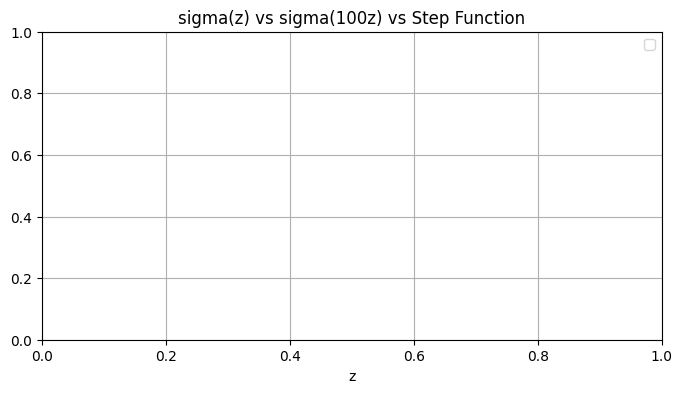

In [16]:
z = np.linspace(-2, 2, 1000)

# TODO: compute sigma(z), sigma(100*z), step function

plt.figure(figsize=(8, 4))
# TODO: plot all three
plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [17]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **Your answer:**

Final w = 0.0000, b = 0.0000


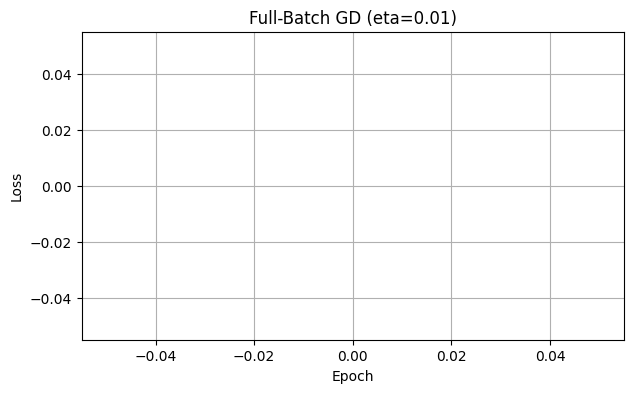

In [18]:
w, b = 0.0, 0.0
eta = 0.01
losses = []

for epoch in range(200):
    # TODO: predictions, loss, gradients, update
    loss = None
    losses.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.grid(True)
plt.show()

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:**

Final w = 0.0000, b = 0.0000


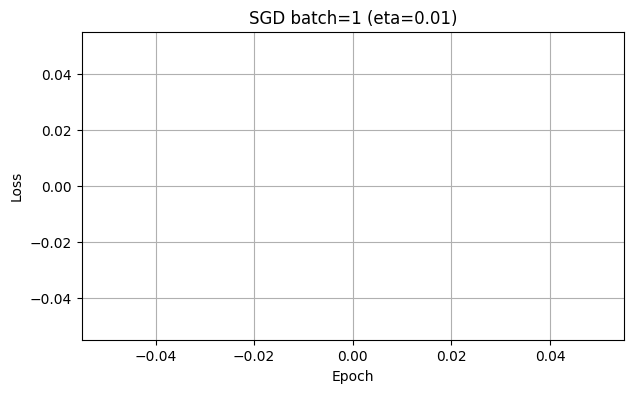

In [19]:
w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []

for epoch in range(200):
    # TODO: pick random example, compute gradient, update
    loss = None
    losses_sgd.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:**

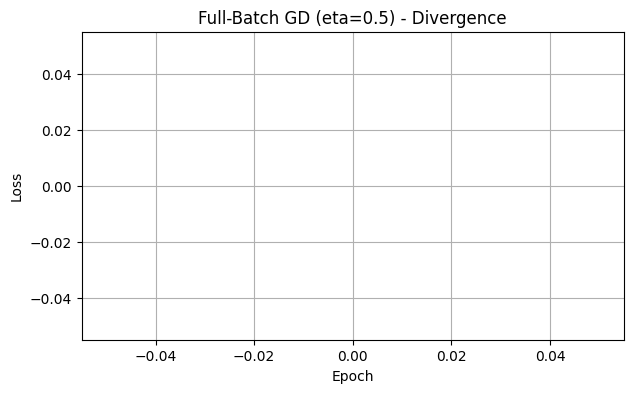

In [20]:
w, b = 0.0, 0.0
losses_div = []

for epoch in range(50):
    # TODO: full-batch GD with eta=0.5
    loss = None
    losses_div.append(loss)
    if loss is not None and not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **Your answer:**

In [21]:
# TODO: define W (4x10) and b_enc (4,)
W     = None  # shape (4, 10)
b_enc = None  # shape (4,)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------


ValueError: matmul: Input operand 0 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:**

In [ ]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

# TODO: run gradient descent steps and annotate on the curve
plt.figure(figsize=(7, 4))
plt.plot(v_vals, C_v, label='C(v)')
plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:**